### **Walmart Sales Forecasting - EDA**

**Objective**
- The goal of this notebook is to analyze historical Walmart sales data to identify patterns, trends, and key drivers of sales.

**Scope**
- Sales trends over time
- Holiday impact
- Store and department performance
- Effect of promotions and external factors

**Outcome**
- Insights from this analysis will guide feature engineering and improve forecasting model performance.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

#Data Preparation
#We load the cleaned dataset generated in the previous step.  
#Only training data (`is_train = 1`) is used for EDA to analyze historical patterns.
cleaned_data = pd.read_csv(DATA_PROCESSED / "walmart_clean.csv")
cleaned_data["Date"] = pd.to_datetime(cleaned_data["Date"])

eda_data = cleaned_data[cleaned_data["is_train"] == 1].copy()

print(eda_data.shape)
eda_data.head()

(421570, 17)


,Store,Dept,Date,Weekly_Sales,IsHoliday,is_train,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,1,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,1,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,1,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,1,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,1,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315


### **1. Sales Trend Over Time**

**How do sales vary over time?  
Are there seasonal patterns or long-term trends?**

In [2]:
sales_trend = eda_data.groupby("Date")["Weekly_Sales"].sum().reset_index()
sales_trend.head()

,Date,Weekly_Sales
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


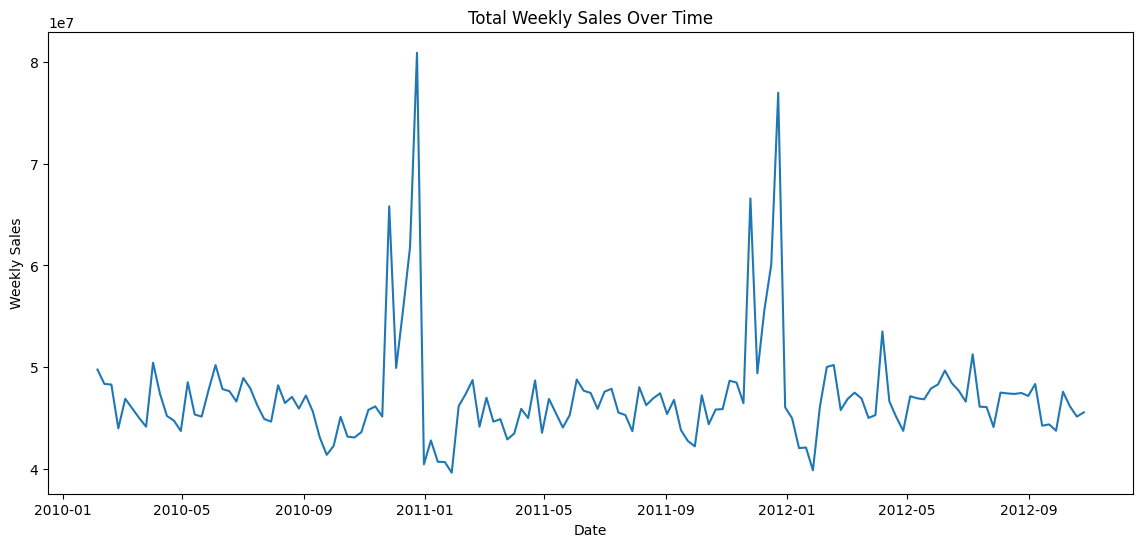

In [ ]:
#Total Weekly Sales Over Time
plt.figure(figsize=(14,6))
plt.plot(sales_trend["Date"], sales_trend["Weekly_Sales"])
plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.show()

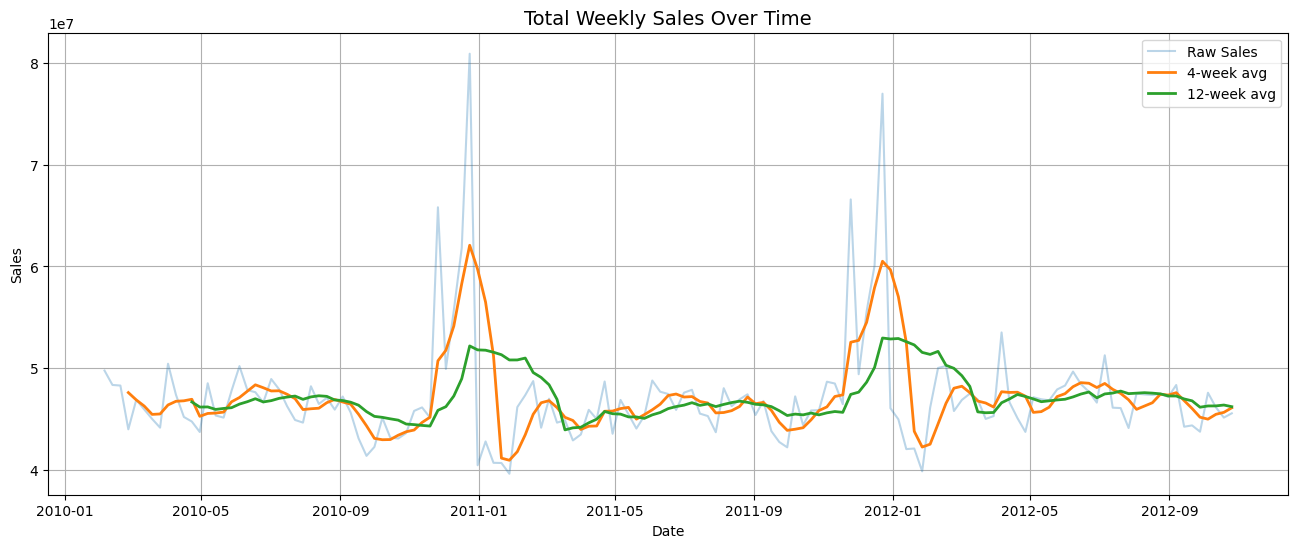

In [ ]:
sales_trend = eda_data.groupby("Date")["Weekly_Sales"].sum().reset_index() #create a new dataframe with total sales by date

sales_trend["rolling_4"] = sales_trend["Weekly_Sales"].rolling(window=4).mean() #calculate 4-week rolling average
sales_trend["rolling_12"] = sales_trend["Weekly_Sales"].rolling(window=12).mean() #calculate 12-week rolling average
plt.figure(figsize=(16,6))

plt.plot(sales_trend["Date"], sales_trend["Weekly_Sales"], 
         alpha=0.3, label="Raw Sales")

plt.plot(sales_trend["Date"], sales_trend["rolling_4"], 
         linewidth=2, label="4-week avg")

plt.plot(sales_trend["Date"], sales_trend["rolling_12"], 
         linewidth=2, label="12-week avg")

plt.title("Total Weekly Sales Over Time", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

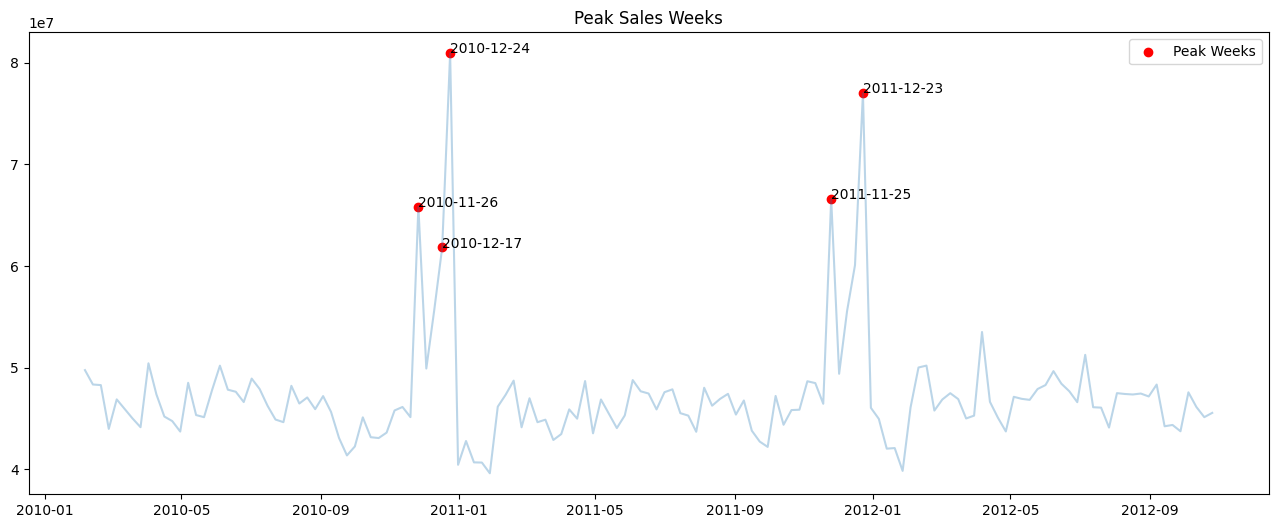

In [ ]:
#Identify peak sales weeks
top_weeks = sales_trend.sort_values("Weekly_Sales", ascending=False).head(5) #get top 5 weeks by sales

plt.figure(figsize=(16,6))
plt.plot(sales_trend["Date"], sales_trend["Weekly_Sales"], alpha=0.3)

plt.scatter(top_weeks["Date"], top_weeks["Weekly_Sales"], 
            color="red", label="Peak Weeks")

for i, row in top_weeks.iterrows():
    plt.text(row["Date"], row["Weekly_Sales"], row["Date"].strftime('%Y-%m-%d'))

plt.title("Peak Sales Weeks")
plt.legend()
plt.show()

In [ ]:
sales_trend.sort_values("Weekly_Sales", ascending=False).head(10) #display top 10 weeks by sales

,Date,Weekly_Sales,rolling_4,rolling_12
46,2010-12-24,80931415.60,6.208200e+07,5.217528e+07
98,2011-12-23,76998241.31,6.050891e+07,5.295494e+07
94,2011-11-25,66593605.26,5.254059e+07,4.740790e+07
42,2010-11-26,65821003.24,5.071334e+07,4.584074e+07
45,2010-12-17,61820799.85,5.830440e+07,4.895098e+07
97,2011-12-16,60085695.94,5.790775e+07,5.005474e+07
44,2010-12-10,55666770.39,5.413060e+07,4.724579e+07
96,2011-12-09,55561147.70,5.449607e+07,4.860744e+07
113,2012-04-06,53502315.87,4.766762e+07,4.658263e+07
126,2012-07-06,51253021.88,4.848263e+07,4.745160e+07


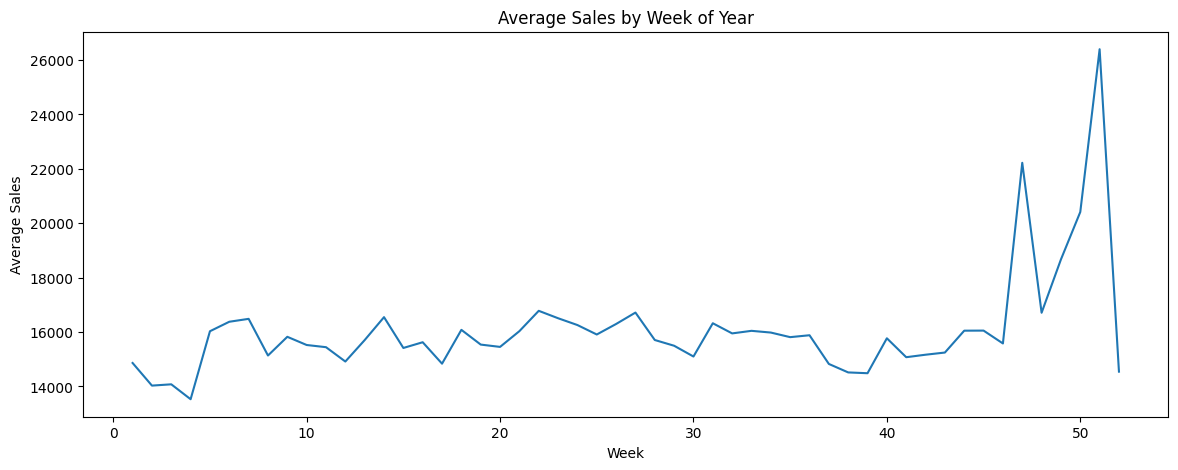

In [ ]:
#Seasonal Patterns: Average Sales by Week of Year
eda_data["Week"] = eda_data["Date"].dt.isocalendar().week #extract week number from date

weekly_pattern = eda_data.groupby("Week")["Weekly_Sales"].mean() #calculate average sales for each week of the year

plt.figure(figsize=(14,5))
weekly_pattern.plot()
plt.title("Average Sales by Week of Year")
plt.xlabel("Week")
plt.ylabel("Average Sales")
plt.show()

In [ ]:
# Yearly Sales Trends
sales_trend["year"] = sales_trend["Date"].dt.year

sales_trend.groupby("year")["Weekly_Sales"].sum()

year
2010    2.288886e+09
2011    2.448200e+09
2012    2.000133e+09
Name: Weekly_Sales, dtype: float64

**Sales across years remain relatively stable, indicating no strong growth trend but consistent seasonal behavior.**

**Sales Trend Insight**

- Weekly sales exhibit strong seasonal patterns with recurring peaks each year.
- The highest sales periods align with major retail events such as Thanksgiving and Christmas.
- Rolling averages confirm that these spikes are consistent year-over-year, indicating predictable seasonal demand.
- There is no strong long-term upward trend, suggesting that sales variability is driven more by seasonality and external factors rather than growth.
- This indicates the need for time-based features such as week-of-year and lag-based features in modeling.

### **2. Holiday Impact Analysis**

**Do holidays significantly influence sales patterns?**

In [ ]:
holiday_sales = eda_data.groupby("IsHoliday")["Weekly_Sales"].agg(["mean", "median", "sum"]) #calculate average, median, and total sales for each holiday category
holiday_sales

,mean,median,sum
IsHoliday,,,
False,15901.445069,7589.95,6.231919e+09
True,17035.823187,7947.74,5.052996e+08


In [11]:
# Grouping sales by the holiday boolean and calculating stats
stats = holiday_sales.groupby('IsHoliday').agg(['mean', 'median', 'sum'])

# Calculating the ratio (Holiday / Non-Holiday) for every metric automatically
ratios = stats.loc[True] / stats.loc[False]
print(ratios)


mean    mean      1.071338
        median    1.071338
        sum       1.071338
median  mean      1.047140
        median    1.047140
        sum       1.047140
sum     mean      0.081082
        median    0.081082
        sum       0.081082
dtype: float64


- Holiday performance shows a strong but concentrated lift, where the average sales increase (7.1%) is being driven by a few high-performing "peak" days rather than a consistent trend.
- While individual holidays are more efficient than regular days, they only contribute about 8% of total revenue, indicating they are too infrequent to be primary business driver.
- Strategically, this suggests a successful "flash sale" model, but long-term growth depends on non-holiday operations.

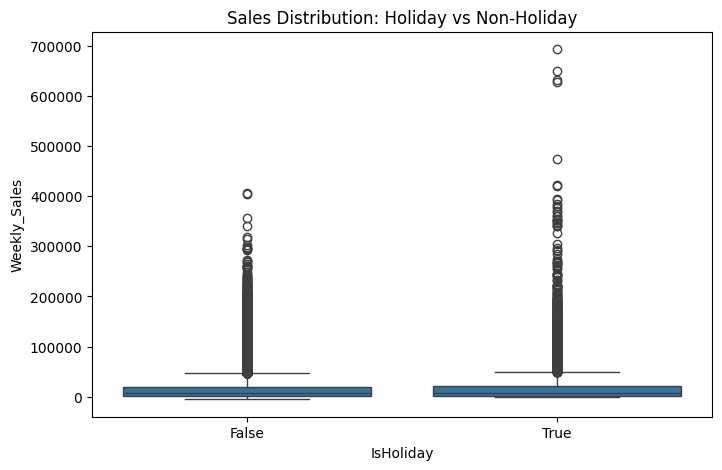

In [ ]:
#Visualize the distribution of sales for holiday vs non-holiday weeks using a boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x="IsHoliday", y="Weekly_Sales", data=eda_data)
plt.title("Sales Distribution: Holiday vs Non-Holiday")
plt.show()

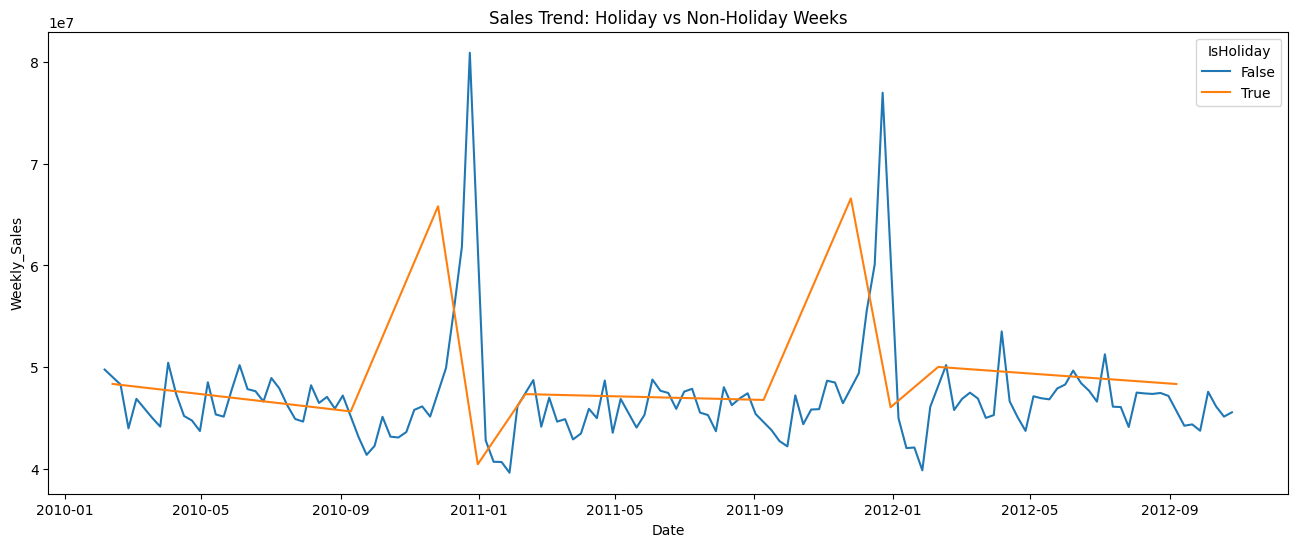

In [ ]:
#Analyze sales trends over time for holiday vs non-holiday weeks using a line plot
holiday_trend = eda_data.groupby(["Date", "IsHoliday"])["Weekly_Sales"].sum().reset_index() #calculate total sales for each date and holiday category

plt.figure(figsize=(16,6))

sns.lineplot(data=holiday_trend, x="Date", y="Weekly_Sales", hue="IsHoliday")

plt.title("Sales Trend: Holiday vs Non-Holiday Weeks")
plt.show()

- Holiday-related spikes occur at consistent periods each year, reinforcing the presence of strong seasonal patterns in the data.
- The sharp increase in sales during holidays combined with high variability suggests that models should account for non-linear effects and interaction between time and promotional features.

**Holiday Impact Insight**

- Holiday weeks exhibit significantly higher average sales compared to non-holiday weeks, confirming strong demand spikes during key retail events.
- The distribution of sales during holidays shows higher variance, indicating unpredictable and volatile demand patterns.
- This suggests that a simple binary holiday indicator may not be sufficient to capture demand behavior.
- Additional features such as lagged holiday effects or proximity to major holidays (e.g., weeks before/after) may improve model performance.

### **3. Store-Level Analysis**

**How does performance vary across stores?**

In [ ]:
store_sales = eda_data.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False) #calculate total sales for each store and sort by sales

store_sales.head()

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
Name: Weekly_Sales, dtype: float64

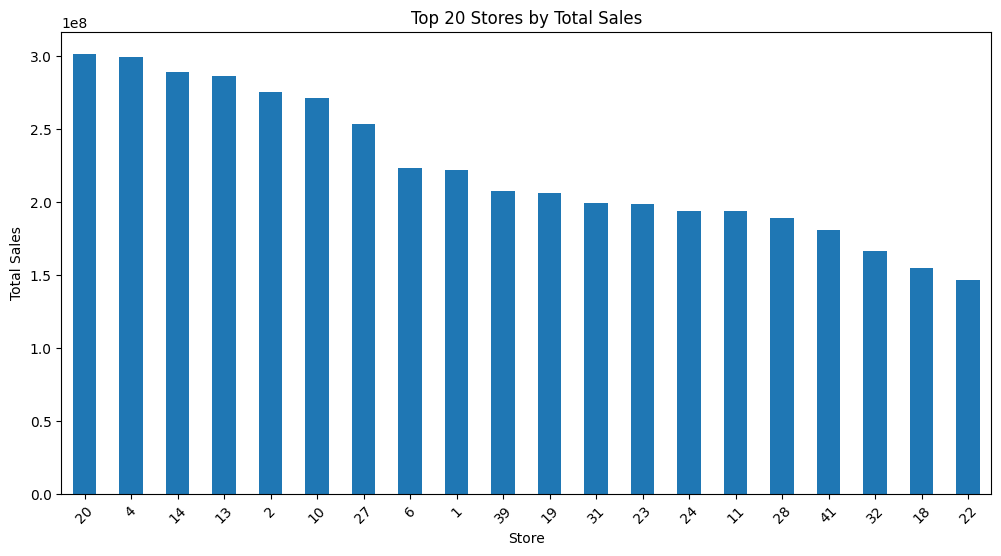

In [ ]:
#Visualize the top 20 stores by total sales using a bar chart
plt.figure(figsize=(12,6))
store_sales.head(20).plot(kind="bar")
plt.title("Top 20 Stores by Total Sales")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

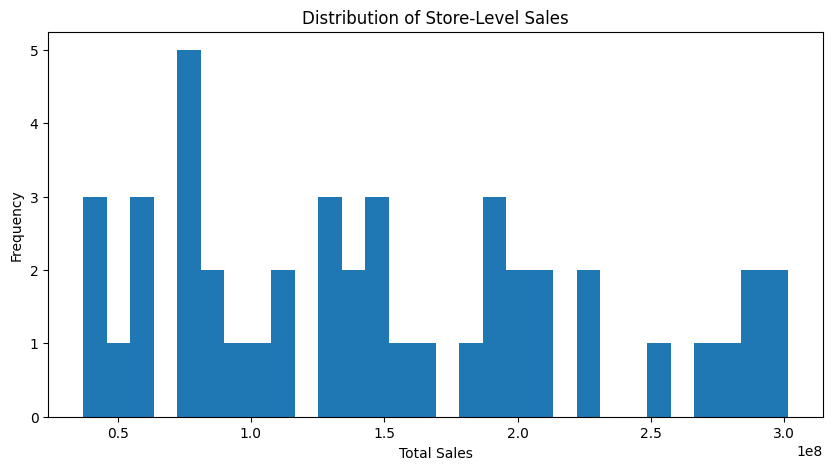

In [ ]:
#Visualize the distribution of sales across all stores using a histogram
plt.figure(figsize=(10,5))
store_sales.plot(kind="hist", bins=30)
plt.title("Distribution of Store-Level Sales")
plt.xlabel("Total Sales")
plt.show()

In [ ]:
store_avg = eda_data.groupby("Store")["Weekly_Sales"].mean().sort_values(ascending=False) #calculate average sales for each store and sort by average sales

store_avg.head()

Store
20    29508.301592
4     29161.210415
14    28784.851727
13    27355.136891
2     26898.070031
Name: Weekly_Sales, dtype: float64

In [ ]:
store_std = eda_data.groupby("Store")["Weekly_Sales"].std().sort_values(ascending=False) #calculate standard deviation of sales for each store and sort by standard deviation

store_std.head()

Store
14    36911.116744
20    35661.530620
4     34583.677814
13    33853.474638
2     33077.612059
Name: Weekly_Sales, dtype: float64

In [ ]:
store_type_sales = eda_data.groupby("Type")["Weekly_Sales"].mean() #calculate average sales for each store type
store_type_sales

Type
A    20099.568043
B    12237.075977
C     9519.532538
Name: Weekly_Sales, dtype: float64

In [ ]:
top_10_share = store_sales.head(10).sum() / store_sales.sum() #calculate the share of total sales contributed by the top 10 stores
top_10_share

np.float64(0.3905053286413301)

Top 10 stores contribute approximately 39.05% of total sales, indicating a highly skewed revenue distribution.

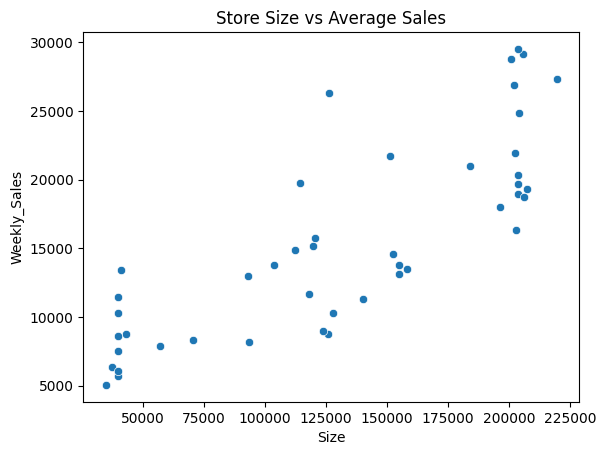

In [ ]:
#Analyze the relationship between store size and average sales using a scatter plot
store_size_sales = eda_data.groupby("Store")["Weekly_Sales"].mean().reset_index() 
store_size_sales = eda_data.groupby("Store").agg({
    "Weekly_Sales": "mean",
    "Size": "first"
}).reset_index() #calculate average sales and get store size for each store, then reset index to turn it back into a dataframe

sns.scatterplot(data=store_size_sales, x="Size", y="Weekly_Sales")
plt.title("Store Size vs Average Sales")
plt.show()

Larger stores tend to generate higher average sales, suggesting store size is an important factor influencing revenue performance.

**Store-Level Insight**

- There is significant variation in total sales across stores, indicating that some stores consistently outperform others.
- The distribution of store-level sales is skewed, with a small number of stores contributing disproportionately to total revenue.
- High variability in certain stores suggests that demand is less predictable, which may impact forecasting accuracy.
- Differences in performance may be influenced by store size, location, and type, which should be incorporated as features.
- This indicates that store-level characteristics are important drivers of sales and should be included in the model.
- Sales patterns vary significantly across stores, suggesting that a single global model may not fully capture store-specific behavior. Incorporating store-level features or segmented modeling approaches could improve performance.

### **4. Department Level Analysis**

**Which departments contribute most to sales?**

In [ ]:
dept_sales = eda_data.groupby("Dept")["Weekly_Sales"].sum().sort_values(ascending=False) #calculate total sales for each department and sort by sales

dept_sales.head()

Dept
92    4.839433e+08
95    4.493202e+08
38    3.931181e+08
72    3.057252e+08
90    2.910685e+08
Name: Weekly_Sales, dtype: float64

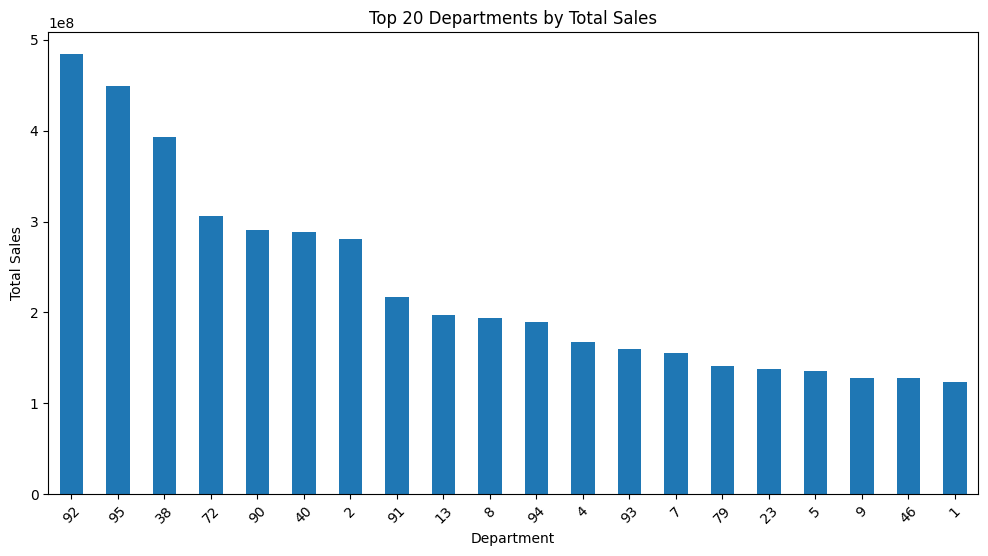

In [ ]:
#Visualize the top 20 departments by total sales using a bar chart
plt.figure(figsize=(12,6))
dept_sales.head(20).plot(kind="bar")
plt.title("Top 20 Departments by Total Sales")
plt.xlabel("Department")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

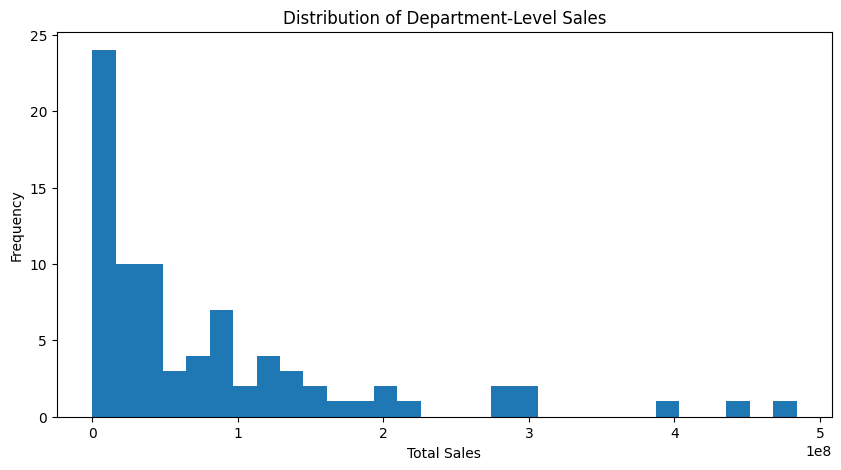

In [ ]:
#Visualize the distribution of sales across all departments using a histogram
plt.figure(figsize=(10,5))
dept_sales.plot(kind="hist", bins=30)
plt.title("Distribution of Department-Level Sales")
plt.xlabel("Total Sales")
plt.show()

In [ ]:
dept_avg = eda_data.groupby("Dept")["Weekly_Sales"].mean().sort_values(ascending=False) #calculate average sales for each department and sort by average sales

dept_avg.head()

Dept
92    75204.870531
95    69824.423080
38    61090.619568
72    50566.515417
65    45441.706224
Name: Weekly_Sales, dtype: float64

In [ ]:
dept_std = eda_data.groupby("Dept")["Weekly_Sales"].std().sort_values(ascending=False) #calculate standard deviation of sales for each department and sort by standard deviation

dept_std.head()

Dept
92    49413.732570
72    44710.982652
95    38200.536452
90    32462.020077
7     27985.082741
Name: Weekly_Sales, dtype: float64

In [ ]:
top_10_dept_share = dept_sales.head(10).sum() / dept_sales.sum() #calculate the share of total sales contributed by the top 10 departments
top_10_dept_share

np.float64(0.46029474713872276)

Top 10 departments contribute approximately 46.03% of total sales, indicating a highly concentrated revenue distribution.

In [ ]:
dept_store = eda_data.groupby(["Dept", "Store"])["Weekly_Sales"].mean().reset_index() #calculate average sales for each department-store combination and reset index to turn it back into a dataframe
print(dept_store.head())

   Dept  Store  Weekly_Sales
0     1      1  22513.322937
1     1      2  30777.980769
2     1      3   7328.621049
3     1      4  36979.940070
4     1      5   9774.553077


**Department-Level Insight**

- Sales are highly concentrated in a small number of departments, with the top departments contributing a significant portion of total revenue.
- The distribution of department-level sales is heavily skewed, indicating that not all departments perform equally.
- Some departments exhibit high variability in sales, suggesting fluctuating demand patterns.
- This variation indicates that department-level characteristics are critical drivers of sales performance.
- Incorporating department-level features and interactions will be important for improving forecasting accuracy.
- Certain departments may be more sensitive to seasonality and promotions, suggesting that interactions between department, time, and markdown features could significantly improve model performance.
- The variation in sales across departments suggests that incorporating department-level features and interactions will be important for improving model performance.
- Different departments may exhibit varying sensitivity to seasonality and promotions, indicating that interaction effects between department, time, and markdown features could enhance forecasting accuracy.

### **5. Markdown & External Features Impact**

**What external factors influence sales?**

**5.1 Markdown Impact**

In [29]:
#Create a combined feature for total markdowns
eda_data["Total_MarkDown"] = eda_data[
    ["MarkDown1","MarkDown2","MarkDown3","MarkDown4","MarkDown5"]
].sum(axis=1)

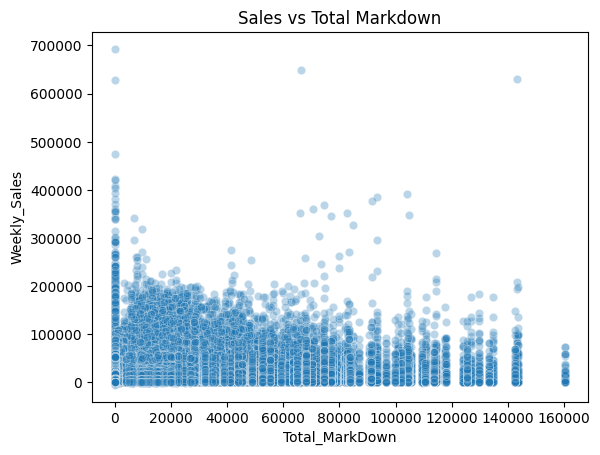

In [30]:
#Compare Sales vs Markdowns
sns.scatterplot(data=eda_data, x="Total_MarkDown", y="Weekly_Sales", alpha=0.3)
plt.title("Sales vs Total Markdown")
plt.show()

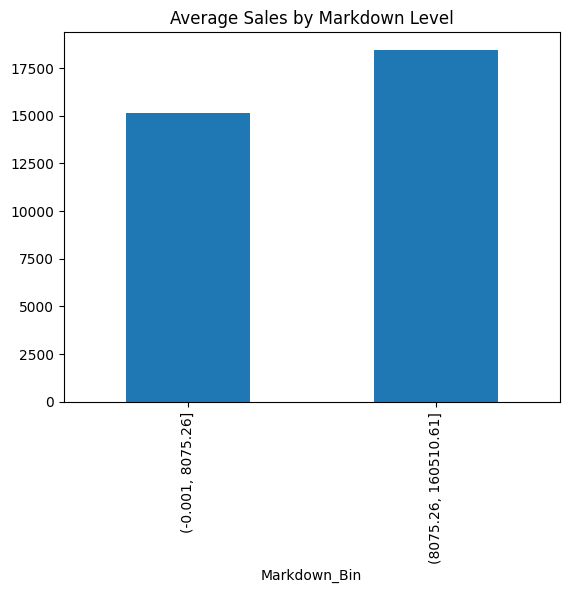

In [31]:
#For stronger view create bins for markdowns
eda_data["Markdown_Bin"] = pd.qcut(eda_data["Total_MarkDown"], q=4, duplicates="drop")

markdown_effect = eda_data.groupby("Markdown_Bin")["Weekly_Sales"].mean()

markdown_effect.plot(kind="bar")
plt.title("Average Sales by Markdown Level")
plt.show()

**Markdown Impact Insight**

- Markdown shows weak linear correlation with sales, but binning analysis indicates higher markdown levels are associated with increased average sales. This suggests a non-linear and context-dependent relationship.

**5.2 Economic Features**

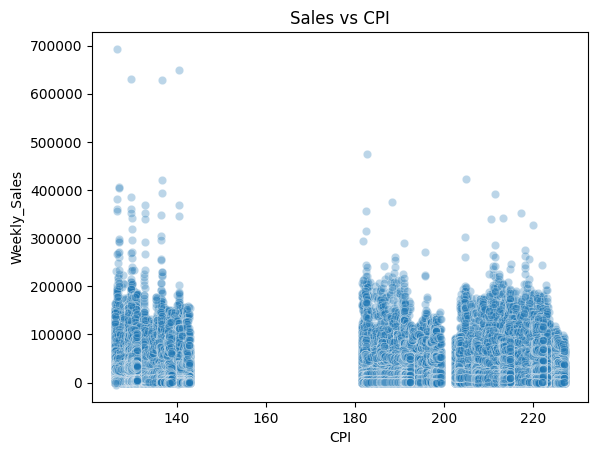

In [32]:
#CPI vs Sales
sns.scatterplot(data=eda_data, x="CPI", y="Weekly_Sales", alpha=0.3)
plt.title("Sales vs CPI")
plt.show()

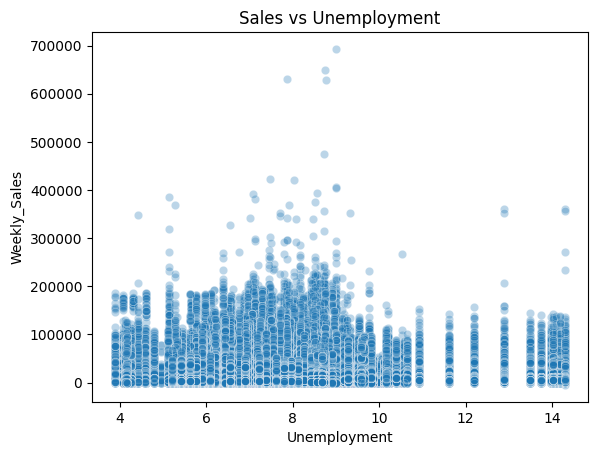

In [33]:
#Unemployment vs Sales
sns.scatterplot(data=eda_data, x="Unemployment", y="Weekly_Sales", alpha=0.3)
plt.title("Sales vs Unemployment")
plt.show()

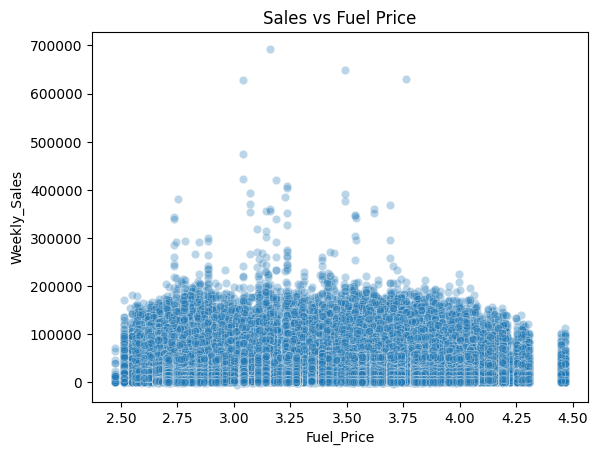

In [34]:
#Fuel Price vs Sales
sns.scatterplot(data=eda_data, x="Fuel_Price", y="Weekly_Sales", alpha=0.3)
plt.title("Sales vs Fuel Price")
plt.show()

**Economic Features Insight**

- Economic variables such as CPI and unemployment show weak direct correlations, suggesting their effects may be indirect, lagged, or mediated through other variables.
- The impact of these variables may be indirect or lagged rather than immediate.
- Fuel price does not exhibit a strong direct correlation with sales in this dataset.
- These features may still contribute to the model when combined with other variables.

**5.3 Weather Impact**

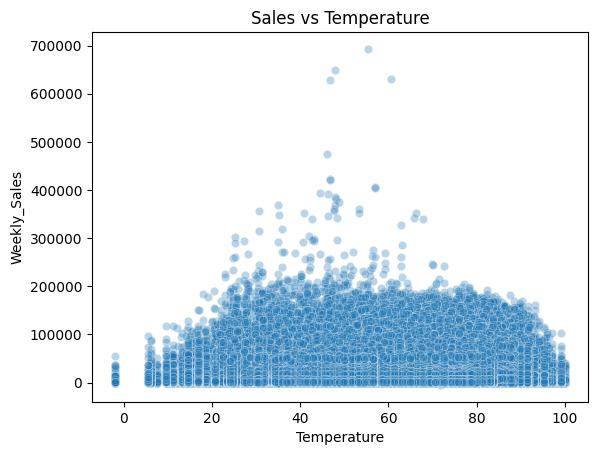

In [35]:
#Temperature vs Sales
sns.scatterplot(data=eda_data, x="Temperature", y="Weekly_Sales", alpha=0.3)
plt.title("Sales vs Temperature")
plt.show()

**Weather Impact Insight**

- Temperature does not show a strong linear relationship with sales.
- The effect of weather may vary across departments (e.g., seasonal products).
- This suggests that interaction features (Temperature × Department) could be more useful.

**5.4 Correlation Matrix**

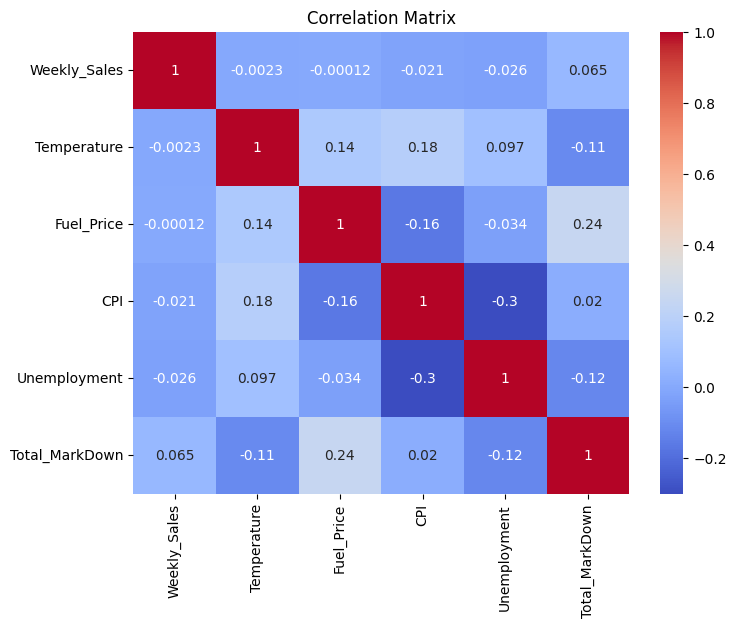

In [ ]:
#Correlation Matrix
corr = eda_data[[
    "Weekly_Sales",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "Total_MarkDown"
]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
eda_data[["Total_MarkDown", "Weekly_Sales"]].corr() #calculate correlation between total markdown and weekly sales

,Total_MarkDown,Weekly_Sales
Total_MarkDown,1.000000,0.065237
Weekly_Sales,0.065237,1.000000


**Markdown Correlation Insight**

- The correlation between total markdown and weekly sales is relatively weak (~0.06), indicating a weak linear relationship.
- However, this does not imply that markdowns have no impact on sales.
- The relationship is likely non-linear and varies across stores, departments, and time periods.
- Earlier analysis using binning showed that higher markdown levels are associated with higher average sales, suggesting that promotions do influence demand.
- This indicates that simple correlation is insufficient, and more complex features or models are needed to capture the impact of markdowns.

**Feature Impact Summary**

- Markdown variables have the strongest observable relationship with sales, confirming the importance of promotions.
- Higher markdown levels lead to increased sales but may exhibit diminishing returns, suggesting that promotional impact is non-linear.
- External economic variables show weak direct correlations, suggesting their effects may be indirect.
- Weather variables do not show strong linear relationships but may influence specific product categories.
- Overall, feature interactions and time-based effects are likely more important than individual feature correlations.
- The weak linear relationships observed in external variables suggest that non-linear models or interaction-based features may better capture their impact on sales.
- Interactions between markdown, department, and time features are likely to significantly improve model performance.

**Feature Engineering Plan**\
Based on EDA, the following features will be created:

- Time-based features (week, month, year)
- Lag features (previous weeks’ sales)
- Rolling averages
- Holiday features
- Markdown aggregations
- Interaction features (Store × Dept, Markdown × Holiday)

**Next Step**
- Proceed to feature engineering to transform these insights into predictive features.
